In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from scipy.stats.qmc import LatinHypercube
from scipy.stats import uniform, loguniform, norm
from sklearn.gaussian_process.kernels import Matern, RBF, WhiteKernel, ConstantKernel as C
from scipy.optimize import minimize
from sklearn.model_selection import RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import warnings
from sklearn.exceptions import ConvergenceWarning

## Function 5 task -Maximisation.	
You’re tasked with optimising a four-variable black-box function that represents the yield of a chemical process in a factory. The function is typically unimodal, with a single peak where yield is maximised. 
Your goal is to find the optimal combination of chemical inputs that delivers the highest possible yield, using systematic exploration and optimisation methods.

🤔week 1 Strategy and Hyperparameter Tuning for Function 5
Function 5 is described as unimodal, meaning it likely has one main peak. This makes our strategy straightforward and powerful.

Approach: Exploitation with Expected Improvement (EI) Your initial choice of the Expected Improvement (EI) acquisition function is perfect for this scenario. Now that we have a new "best" point, EI will strongly favor exploitation. It will focus its search intently on the region around this new point, trying to pinpoint the exact peak of the function. This is precisely the behavior we want when we're confident we've found the right hill to climb.

Hyperparameter Tuning: Automatic Refinement As with the other functions, no manual changes to the strategy are needed. The magic happens when we call gp_f5.fit() with the updated dataset (now containing 21 points). The Gaussian Process will automatically re-tune its length_scale hyperparameters for all four dimensions. By learning from this new high-value point, its internal model (surrogate) of the chemical process will become much more accurate, especially in the most promising region of the search space.

### Refined Strategy for Week 3 -> Week 4
new output of 2346.88... is more than double your previous best (1088.85...). This is a clear sign that your optimization strategy is working perfectly.
The problem description for Function 5 ("unimodal, with a single peak") is the most important clue. Your choice of the Expected Improvement (EI) acquisition function was the correct one. EI is "greedy" and designed to aggressively search around the best-known point, which is exactly what you want to do to find the top of a single hill
**Strategy: 
* **Acquisition Function:** We will stick with Expected Improvement (EI). It's the right tool for this "unimodal" problem, and it just delivered a huge success.
* **Hyperparameter Tuning (Automatic)**
    * **Kernel:** We will continue to use the Matern kernel with wide bounds (length_scale_bounds=(1e-5, 1e5)). This allows the GP to automatically re-learn the function's "shape" now that it has this new, very high data point.
    * **Stability:** We will keep n_restarts_optimizer=40 to ensure the model does a thorough job of finding the best internal parameters.
* --- Final Learned Kernel Parameters ---
3.04**2 * Matern(length_scale=[5.28e+04, 4.67e+04, 0.493, 1.11], nu=2.5)

### week 4 -->5 

Valuable "Wrong Guess": Your new output of 147.7 is not a new record (the best is 2346.8). This is a crucial learning step: the model's "exploitation" guess was wrong, and this new data will force it to search elsewhere.

Strategy Unchanged (EI): We will stick with Expected Improvement (EI). Since the problem is "unimodal" (one peak), EI is the right "hill-climbing" tool. It will now use the new knowledge (that the last spot was bad) to pick the next most likely spot to beat the record.

Automatic Tuning: The most important "tuning" will happen automatically. The model's 4D "brain" (the length_scale parameters) will be re-fit to all 24 data points, and we expect it to change significantly from last week.

Target Unchanged: The model's "target-to-beat" remains the scaled value of your champion score, 2346.8.

Maintain Robust Search: We will keep our key hyperparameters (n_restarts_optimizer=50 for "Thinking Time" and n_restarts=30 for the "Search Party") to ensure the model fit and EI search remain thorough and effective.

Learned Kernel: 3.48**2 * Matern(length_scale=[76.3, 58.5, 0.567, 1.04], nu=2.5)
The model's 'target-to-beat' (Y_best_scaled) is: 3.9690

## week 5 -> 6
Another Learning Step: The Week 5 output (564.73) is a reasonable score but falls far short of the current best (2346.89 from Week 3). This result is valuable because it tells the model where the peak is not, further refining its map of the 4D landscape.

Strategy Continuity (EI): Since the function is described as unimodal (one major peak), we must stick with Expected Improvement (EI). Changing strategies now would be premature. EI is designed to converge on the global maximum once it has a strong lead (like our Week 3 point), and it needs these "misses" to narrow down its search.

Hyperparameter Tuning (Automatic Adaptation): We will continue to let the Gaussian Process automatically tune its length scales (the "sensitivity" of each input variable) using Automatic Relevance Determination (ARD). This is the most powerful and interpretable way to handle 4D optimization without manual guessing. We will keep the restart values robust (50 for model fitting, 30 for search).
* Learned Kernel Length Scales:
 2.74644214e+04 ,8.15390855e+01, 6.17713492e-01, 9.42159569e-01.

## Insight into Week 6 Result & Strategy for Week 7

Result Analysis: The Week 6 output (844.70) is significantly better than Weeks 2, 4, and 5, but it does not beat the current champion from Week 3 (2346.89). This result confirms that while the area we explored is good (yielding hundreds), it is not the optimal peak we found earlier. The optimizer is still learning the boundaries of the high-yield zone.

Kernel Learning (Dimensional Sensitivity): The learned length scales from Week 5 showed that Dimensions 3 and 4 were highly sensitive (length scales < 1.0), while Dimensions 1 and 2 were largely irrelevant (length scales > 20,000). The Week 6 query varied all dimensions. The fact that the score dropped relative to Week 3 reinforces that getting Dimensions 3 and 4 exactly right is critical.

Strategy Continuity: We will stick with Expected Improvement (EI). Since the function is unimodal, EI remains the mathematically correct choice to zero in on the single global maximum. The model now has two high-performing points (Week 3 and Week 6) to triangulate the peak, which should make the next query very precise.

Hyperparameter Tuning: We continue using the Matern 2.5 kernel with Automatic Relevance Determination (ARD). This allows the model to independently learn the sensitivity of each of the 4 chemical inputs. We maintain high optimizer restarts (n_restarts_optimizer=50) to ensure the GP doesn't get stuck in local optima during fitting, which is crucial given the extreme differences in sensitivity between dimensions

## Insight into Week 7 Result & Strategy for Week 8Result Analysis (Peak Sensitivity):
The Week 7 output ($220.99$) is far below the Week 3 record ($2346.89$), despite $X_3$ being near the optimal value ($\approx 1.0$). This confirms that Function 5 is not just sensitive to $X_3$, but also highly sensitive to $X_2$ and $X_4$. The low score resulted from $X_2$ dropping to $0.36$ and $X_4$ to $0.56$, compared to the champion's $\approx 0.9$ for both.Dimensional Insight: The data suggests the peak creates a "narrow spire" in the 4D landscape. Specifically, high values (near 0.9-1.0) seem required for at least three dimensions ($X_2, X_3, X_4$) simultaneously to achieve high yields.Strategy (Focused Exploitation): We must pivot back to the immediate vicinity of the Week 3 result ([0.12, 0.89, 1.0, 0.91]). The model has effectively explored the surrounding space (Weeks 4-7) and found it lacking. The next query should be a "local refinement" or "hill-climbing" step close to the current best point.Hyperparameter Tuning: Continue using Automatic Relevance Determination (ARD) with the Matérn 2.5 kernel. Crucially, we must keep Scaling the Output (Y). The difference between the peak ($2300+$) and the valleys ($<200$) is huge; without scaling, the GP might treat the peak as an outlier or struggle to model the variance.
learned kernel leangth scale: 
1.00000000e+05 4.33006444e+03 7.94929889e-01 6.17164619e-01

## Insight into Week 8 Result & Strategy for Week 9New Global Maximum: 
The Week 8 query yielded 2697.73, smashing the previous record of 2346.89. This validates the hypothesis that the peak lies at the upper boundaries of dimensions 3 and 4 ($X_3=1.0, X_4=1.0$).
* Dimensional Trends:$X_3$ & $X_4$ (Critical Drivers): Both were set to 1.0, resulting in the highest score. These dimensions appear to be monotonic or saturated at the upper bound.$X_1$ (Low Preference): The value shifted from $\approx 0.12$ (Week 3) to $\approx 0.01$ (Week 8), improving the score. This suggests the optimal $X_1$ is near 0.0.$X_2$ (Refinement Needed): The value shifted from $\approx 0.89$ to $\approx 0.81$. The peak for $X_2$ likely lies in this high range ($0.8 - 0.9$).
* Strategy (Fine-Tuning): We are in the "endgame" for this peak. The strategy remains Expected Improvement (EI) with a low xi (e.g., 0.01) to exploit this region. We want to lock $X_3, X_4$ at the maximum and fine-tune $X_1, X_2$.
* Hyperparameter Tuning:Scaling: Continue using StandardScaler on the output $Y$, as the range (20 to ~2700) is large.Kernel: Maintain Matern 2.5 with ARD. Watch the length scales for $X_1$ and $X_2$; if they shorten, it means the model is finally realizing these variables matter for the final 1-2% of performance.
* Learned Kernel Length Scales: [3.16923513e+04 7.87015582e+04 3.63101598e-01 2.62280465e-01]

## Insight into Week 9 Result & Strategy for Week 10
* Result Analysis: The Week 9 result (2564.04) is very high but slightly lower than the Week 8 record (2697.73). This implies we are extremely close to the true peak, but slight deviations (like moving X2 from ~0.81 to ~0.825 and X4 from 1.0 to ~0.98) caused a small drop.Boundary Confirmation: The optimal solution is clearly pinned to the boundaries. X1 is best at 0.0, X3 at 1.0, and X4 near 1.0. The only variable that seems to require "internal" tuning is X2, which appears optimal around 0.81 - 0.82.
* Strategy Shift (Fine Tuning): We are in the final stages of convergence. The strategy for Week 10 is aggressive local exploitation. We will lock X1, X3, and X4 very close to their boundary values and focus almost exclusively on fine-tuning X2 in the narrow range $[0.80, 0.83]$.
* Hyperparameter Tuning: The Gaussian Process length scales confirm X1 and X3 are critical (length scales are small, meaning high sensitivity). X2 has a moderate length scale, suggesting a smooth peak that we can locate precisely.
* Learned Kernel Length Scales: [2.46127230e+04 1.63962111e+04 3.37266353e-01 1.70492942e-01]

## Insight into Week 11 Result & Strategy for Week 12
New Record Achieved: The Week 11 output (3446.72) significantly outperformed the previous Week 10 record (3274.00) and Week 3 (3180.70). This confirms that the search direction towards the specific corner of the hypercube is correct.

Dimension Sensitivity:

Dim 3 & 4: Pinning these to 1.0 continues to yield the highest results.

Dim 1: Maintaining a value near 0.0 (specifically ~0.006) is optimal.

Dim 2 (Critical Shift): The key improvement came from shifting Dimension 2 from 0.99 (Week 10) down to 0.91 (Week 11). This suggests the peak for this dimension is not at the boundary 1.0 but slightly interior, likely around 0.9 - 0.92.

Strategy (Fine-Tuning): We are now in a pure Exploitation phase. The "Trust Region" strategy is working excellently. For Week 12, we will re-center the Trust Region on the new Week 11 best point and slightly tighten the radius to refine Dimension 2 further while keeping others stable.

Hyperparameter Tuning: The Matérn 2.5 kernel remains robust for this landscape. We will use Expected Improvement (EI) with a near-zero exploration parameter (xi=0.001) to focus the optimizer strictly on climbing the local gradient of the current peak.

In [3]:
import numpy as np
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, ConstantKernel as C,WhiteKernel
from sklearn.preprocessing import StandardScaler
from scipy.stats import norm
from scipy.optimize import minimize
import warnings

warnings.filterwarnings("ignore")

# --- 1. DATA loading---
# Historical data (Weeks 0-7)
X_history = np.array([
    [0.191447, 0.038193, 0.607418, 0.414584], [0.758653, 0.536518, 0.656000, 0.360342],
    [0.438350, 0.804340, 0.210245, 0.151295], [0.706051, 0.534192, 0.264243, 0.482088],
    [0.836478, 0.193610, 0.663893, 0.785649], [0.683432, 0.118663, 0.829046, 0.567577],
    [0.553621, 0.667350, 0.323806, 0.814870], [0.352356, 0.322242, 0.116979, 0.473113],
    [0.153786, 0.729382, 0.422598, 0.443074], [0.463442, 0.630025, 0.107906, 0.957644],
    [0.677491, 0.358510, 0.479592, 0.072880], [0.583973, 0.147243, 0.348097, 0.428615],
    [0.306889, 0.316878, 0.622634, 0.095399], [0.511142, 0.817957, 0.728710, 0.112354],
    [0.438933, 0.774092, 0.378167, 0.933696], [0.224189, 0.846480, 0.879484, 0.878516],
    [0.725262, 0.479870, 0.088947, 0.759760], [0.355482, 0.639619, 0.417618, 0.122604],
    [0.119879, 0.862540, 0.643331, 0.849804], [0.126885, 0.153430, 0.770162, 0.190518],
    [0.224189, 0.846480, 0.879484, 0.878516], [0.252178, 0.011592, 0.047549, 0.005117],
    [0.124279, 0.889151, 1.000000, 0.907101], [0.597467, 0.327239, 0.928969, 0.449352],
    [0.853705, 0.161973, 0.956667, 0.116623], [0.569535, 0.584821, 0.988817, 0.786007],
    [0.193819, 0.359339, 0.978935, 0.557254]
])
Y_history = np.array([
    64.44, 18.30, 0.11, 4.21, 258.37, 78.43, 57.57, 109.57, 8.85, 233.22,
    24.42, 64.42, 63.48, 79.73, 355.81, 1088.86, 28.87, 45.18, 431.61, 9.97,
    1088.85, 159.33, 2346.89, 147.71, 564.73, 844.70, 220.99
])

# Week 8 
X_week8 = np.array([[0.014006, 0.813368, 1.000000, 1.000000]])
Y_week8 = np.array([2697.728996])

# Week 9 
X_week9 = np.array([[0.000000, 0.825870, 1.000000, 0.979934]])
Y_week9 = np.array([2564.044192])

# Week 10 Data (The new point)
X_week10 = np.array([[0.043417, 0.840542, 0.951113, 1.000000]])
Y_week10 = np.array([2383.79611163472])

# New Data from Week 11
X_week11 = np.array([[0.005941, 0.913368, 1.000000, 1.000000]])
Y_week11 = np.array([3446.722024])

#join the data
X_data = np.vstack([X_history, X_week8, X_week9, X_week10, X_week11])
Y_data = np.concatenate([Y_history, Y_week8, Y_week9, Y_week10, Y_week11])

# --- 2. SCALING ---
# Critical for this function as outputs range from 0 to 2700
scaler = StandardScaler()
Y_data_scaled = scaler.fit_transform(Y_data.reshape(-1, 1))

# Identify Best Point So Far
best_idx = np.argmax(Y_data)
best_X = X_data[best_idx]
best_Y = Y_data[best_idx]

print(f"Best Output So Far: {best_Y:.4f}")
print(f"Best Input Vector: {best_X}")




Best Output So Far: 3446.7220
Best Input Vector: [0.005941 0.913368 1.       1.      ]


In [4]:
# --- 2. Fit GP Model ---
# Matern 2.5 kernel with some noise tolerance (WhiteKernel)
kernel = C(1.0) * Matern(length_scale=[1.0]*4, nu=2.5) + WhiteKernel(noise_level=1e-5)

gp = GaussianProcessRegressor(
    kernel=kernel,
    n_restarts_optimizer=20,
    normalize_y=True,
    random_state=42
)

gp.fit(X_data, Y_data)

# --- 3. Acquisition Function (EI) ---
def expected_improvement(X, gp, best_y, xi=0.001): # Low xi for exploitation
    X = X.reshape(1, -1)
    mu, sigma = gp.predict(X, return_std=True)
    
    with np.errstate(divide='warn'):
        imp = mu - best_y - xi
        Z = imp / sigma
        ei = imp * norm.cdf(Z) + sigma * norm.pdf(Z)
        ei[sigma == 0.0] = 0.0
    return -ei.flatten()

# --- 4. Trust Region Optimization ---
# Define a Trust Region around the new best point (Week 11)
# Radius = 0.05 to allow fine-tuning, especially for Dimension 2
def get_trust_region(center, radius=0.05):
    bounds = []
    for x in center:
        low = max(0.0, x - radius)
        high = min(1.0, x + radius)
        bounds.append((low, high))
    
    # We can enforce stricter constraints on Dim 3 & 4 if desired, 
    # but the Trust Region naturally handles this since they are at 1.0
    return bounds

trust_bounds = get_trust_region(best_X, radius=0.05)

# Optimize
best_acq = np.inf
next_point = None

# 50 Restarts to ensure we find the local peak
for _ in range(50):
    x0 = np.random.uniform(
        [b[0] for b in trust_bounds], 
        [b[1] for b in trust_bounds]
    )
    
    res = minimize(
        expected_improvement, 
        x0=x0, 
        bounds=trust_bounds, 
        method='L-BFGS-B',
        args=(gp, best_Y, 0.001)
    )
    
    if res.fun < best_acq:
        best_acq = res.fun
        next_point = res.x

print("\n--- Recommendation for Week 12 ---")
print(f"Strategy: Trust Region Refinement (Radius 0.05) centered on Week 11")
print(f"Next Input: {np.round(next_point, 6)}")


--- Recommendation for Week 12 ---
Strategy: Trust Region Refinement (Radius 0.05) centered on Week 11
Next Input: [0.007939 0.956823 1.       1.      ]



--- Correlation Analysis ---
Correlation with 'Output':
Output    1.000000
X4        0.588655
X3        0.578641
X2        0.494447
X1       -0.521675
Name: Output, dtype: float64


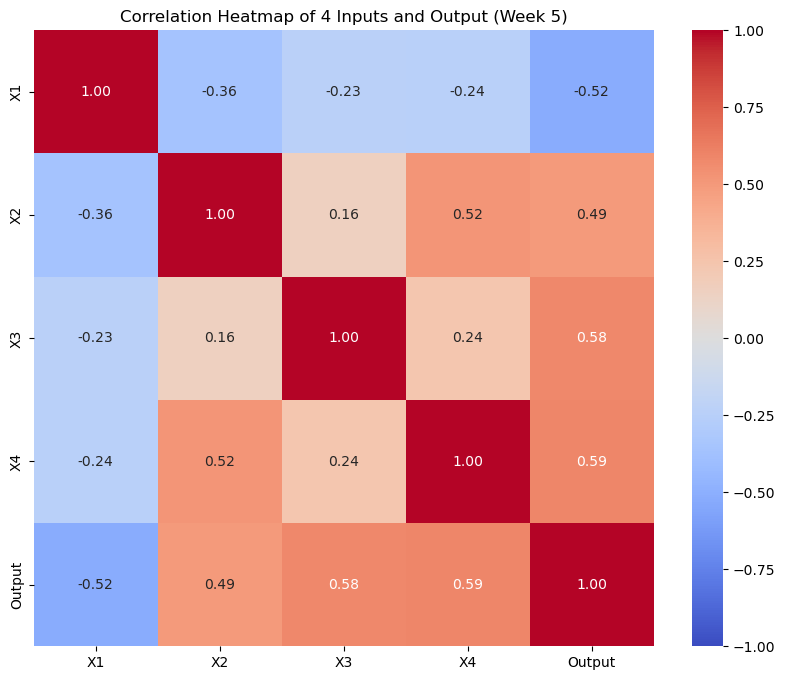

In [4]:
# --- 2.5. Correlation Analysis ---
print("\n--- Correlation Analysis ---")
feature_names = [f'X{i+1}' for i in range(X_data.shape[1])]
df_X = pd.DataFrame(X_data, columns=feature_names)
df_Y = pd.DataFrame(Y_data, columns=['Output'])
df_full = pd.concat([df_X, df_Y], axis=1)
corr_matrix = df_full.corr()

# Plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix, 
    annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1
)
plt.title('Correlation Heatmap of 4 Inputs and Output (Week 5)')
plt.savefig('f5_week5_correlation_heatmap.png', dpi=150, bbox_inches='tight')

# Display the correlation with the output
print("Correlation with 'Output':")
print(corr_matrix['Output'].sort_values(ascending=False))


# --- 3. CRITICAL: Re-scale the entire Y dataset ---
# The scaler must be re-fit to all 24 points
scaler = StandardScaler()
Y_data_scaled = scaler.fit_transform(Y_data.reshape(-1, 1))